<a href="https://colab.research.google.com/github/mohamedshehada/chicago-crime-analysis/blob/main/Project_3_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Analysis — Project 3 Part 1
**Topics:** 1 (Districts) · 2 (Yearly Trend) · 3 (Rush Hour) · 4 (Months) · 5 (Seasonality)



## Step 0 — Install & Import

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import holidays
import glob
import os
import zipfile
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print('All imports successful ✅')

All imports successful ✅


## Step 1 — Mount Google Drive & Extract ZIP

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
ZIP_PATH = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/Chicago_Crime_2001-2022.zip'

# Define extraction directory
EXTRACT_DIR = '/content/chicago_data'
os.makedirs(EXTRACT_DIR, exist_ok=True)

print(f'Extracting {ZIP_PATH} ...')
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    # List all files inside the ZIP
    files_in_zip = z.namelist()
    print(f'Files in ZIP ({len(files_in_zip)}):')
    for f in files_in_zip:
        print(f'  {f}')
    # Extract all files into the target directory
    z.extractall(EXTRACT_DIR)

print('\nExtraction complete ✅')


Extracting /content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/Chicago_Crime_2001-2022.zip ...
Files in ZIP (23):
  Data/Chicago-Crime_2001.csv
  Data/Chicago-Crime_2002.csv
  Data/Chicago-Crime_2003.csv
  Data/Chicago-Crime_2004.csv
  Data/Chicago-Crime_2005.csv
  Data/Chicago-Crime_2006.csv
  Data/Chicago-Crime_2007.csv
  Data/Chicago-Crime_2008.csv
  Data/Chicago-Crime_2009.csv
  Data/Chicago-Crime_2010.csv
  Data/Chicago-Crime_2011.csv
  Data/Chicago-Crime_2012.csv
  Data/Chicago-Crime_2013.csv
  Data/Chicago-Crime_2014.csv
  Data/Chicago-Crime_2015.csv
  Data/Chicago-Crime_2016.csv
  Data/Chicago-Crime_2017.csv
  Data/Chicago-Crime_2018.csv
  Data/Chicago-Crime_2019.csv
  Data/Chicago-Crime_2020.csv
  Data/Chicago-Crime_2021.csv
  Data/Chicago-Crime_2022.csv
  Data/README.txt

Extraction complete ✅


## Step 2 — Load All CSV Files

In [7]:
csv_files = sorted(glob.glob(os.path.join(EXTRACT_DIR, '**/*.csv'), recursive=True))

if not csv_files:
    csv_files = sorted(glob.glob(os.path.join(EXTRACT_DIR, '*.csv')))

print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    print(f'  {os.path.basename(f)}')

df_list = []
for f in csv_files:
    temp = pd.read_csv(f, low_memory=False)
    df_list.append(temp)
    print(f'  Loaded: {os.path.basename(f)} — {len(temp):,} rows')

df = pd.concat(df_list, ignore_index=True)
print(f'\nTotal rows: {len(df):,}')
print(f'Columns: {df.columns.tolist()}')

Found 22 CSV files:
  Chicago-Crime_2001.csv
  Chicago-Crime_2002.csv
  Chicago-Crime_2003.csv
  Chicago-Crime_2004.csv
  Chicago-Crime_2005.csv
  Chicago-Crime_2006.csv
  Chicago-Crime_2007.csv
  Chicago-Crime_2008.csv
  Chicago-Crime_2009.csv
  Chicago-Crime_2010.csv
  Chicago-Crime_2011.csv
  Chicago-Crime_2012.csv
  Chicago-Crime_2013.csv
  Chicago-Crime_2014.csv
  Chicago-Crime_2015.csv
  Chicago-Crime_2016.csv
  Chicago-Crime_2017.csv
  Chicago-Crime_2018.csv
  Chicago-Crime_2019.csv
  Chicago-Crime_2020.csv
  Chicago-Crime_2021.csv
  Chicago-Crime_2022.csv
  Loaded: Chicago-Crime_2001.csv — 485,886 rows
  Loaded: Chicago-Crime_2002.csv — 486,807 rows
  Loaded: Chicago-Crime_2003.csv — 475,985 rows
  Loaded: Chicago-Crime_2004.csv — 469,422 rows
  Loaded: Chicago-Crime_2005.csv — 453,773 rows
  Loaded: Chicago-Crime_2006.csv — 448,179 rows
  Loaded: Chicago-Crime_2007.csv — 437,087 rows
  Loaded: Chicago-Crime_2008.csv — 427,183 rows
  Loaded: Chicago-Crime_2009.csv — 392,827 row

## Step 3 — Clean & Prepare Data

In [8]:
# Standardize column names
df.columns = df.columns.str.strip()
print('Columns:', df.columns.tolist())
df.head()

Columns: ['ID', 'Date', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Latitude', 'Longitude']


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


In [9]:
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar

# Parse the 'Date' column into datetime format
df['Date'] = pd.to_datetime(df['Date'], infer_datetime_format=True, errors='coerce')

# Count how many rows had unparseable dates
null_dates = df['Date'].isna().sum()
print(f'Rows with unparseable dates: {null_dates:,}')

# Drop rows where 'Date' could not be parsed
df.dropna(subset=['Date'], inplace=True)

# Set 'Date' as the index and sort the DataFrame chronologically
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Create helper columns for easier analysis
df['Year']  = df.index.year   # Extract year from datetime index
df['Month'] = df.index.month  # Extract month from datetime index
df['Hour']  = df.index.hour   # Extract hour from datetime index

# Create a 'date_only' column (just the date without time)
df['date_only'] = df.index.date

# Print dataset overview
print(f'Date range : {df.index.min()} → {df.index.max()}')
print(f'Total rows : {len(df):,}')

# Preview first 3 rows
df.head(3)

Rows with unparseable dates: 0
Date range : 2001-01-01 00:00:00 → 2022-12-31 23:55:00
Total rows : 7,713,109


,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year,Month,Hour,date_only
Date,,,,,,,,,,,,,,,
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923,2001,1,0,2001-01-01
2001-01-01,1927872,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137,2001,1,0,2001-01-01
2001-01-01,4768442,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707,2001,1,0,2001-01-01


In [10]:
# Form 2: Daily crime counts (resampled)
# - Resample the dataset by day ('D') and count the number of crimes per day
daily_crimes = df.resample('D').size().rename('crime_count')

# Ensure the series has a continuous daily frequency
# - Use asfreq('D') to fill missing days
# - Fill missing values with 0 (days with no crimes recorded)
daily_crimes_filled = daily_crimes.asfreq('D').fillna(0)

# Print summary of the daily crime series
print(f'Daily crimes series: {len(daily_crimes_filled):,} days')

# Preview the first 5 rows
daily_crimes_filled.head()

Daily crimes series: 8,035 days


,crime_count
Date,
2001-01-01,1825
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267


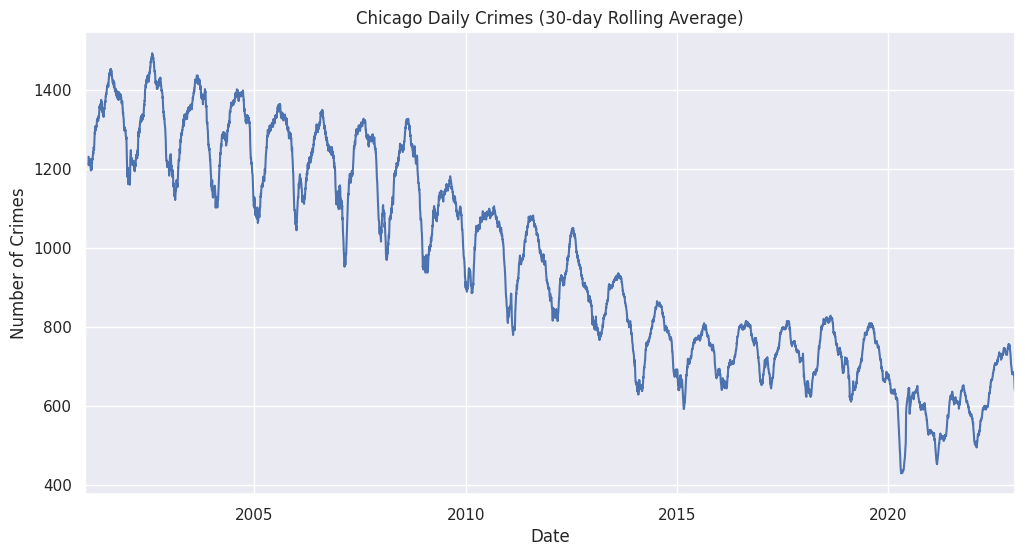

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
daily_crimes_filled.rolling(30).mean().plot()
plt.title("Chicago Daily Crimes (30-day Rolling Average)")
plt.ylabel("Number of Crimes")
plt.xlabel("Date")
plt.show()


---
## 📍 Topic 1 — Comparing Police Districts (2022)

District with MOST crimes in 2022  : District 8  (14,805 crimes)
District with LEAST crimes in 2022 : District 31 (15 crimes)


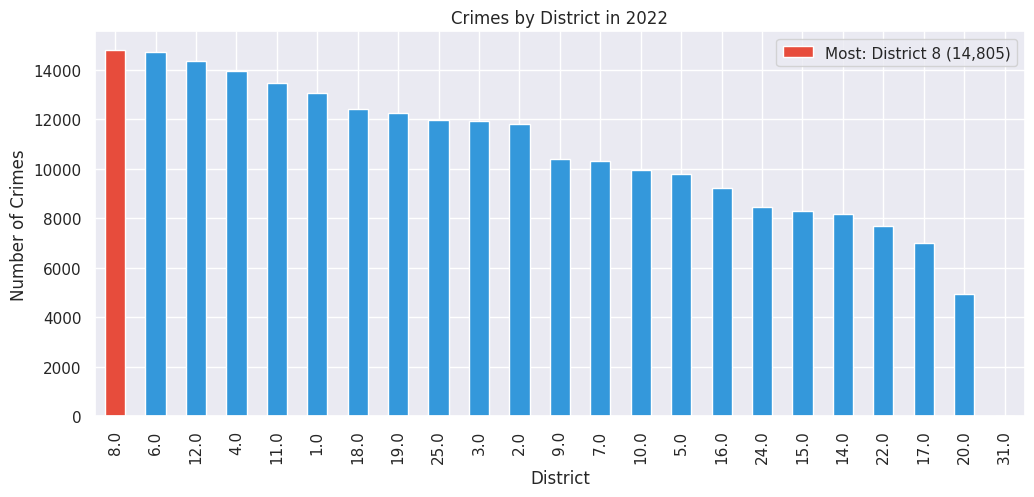

In [12]:
import matplotlib.pyplot as plt

# Filter dataset for 2022
df_2022 = df[df['Year'] == 2022]

# Count crimes per District
district_counts = df_2022['District'].value_counts().dropna()

# Identify most/least
most_d, least_d = district_counts.idxmax(), district_counts.idxmin()
print(f'District with MOST crimes in 2022  : District {int(most_d)}  ({district_counts.max():,} crimes)')
print(f'District with LEAST crimes in 2022 : District {int(least_d)} ({district_counts.min():,} crimes)')

# Assign colors: red for most, green for least, blue for others
colors = ['#e74c3c' if d == most_d else '#2ecc71' if d == least_d else '#3498db'
          for d in district_counts.index]

# Plot bar chart
ax = district_counts.plot(kind='bar', figsize=(12,5), color=colors, edgecolor='white')
plt.title("Crimes by District in 2022")
plt.xlabel("District")
plt.ylabel("Number of Crimes")

# Add legend
plt.legend([
    f"Most: District {int(most_d)} ({district_counts.max():,})",
    f"Least: District {int(least_d)} ({district_counts.min():,})"
])

plt.show()

### 📝 Findings — Topic 1
**The district with the most crimes in 2022 was District 8 with 14,805 crimes.**

**The district with the least crimes in 2022 was District 31 with 15 crimes.**

---
## 📈 Topic 2 — Crimes Across the Years

In [13]:
# Total crimes per year
yearly_crimes = df.groupby('Year').size().rename('total_crimes')
yearly_crimes

,total_crimes
Year,
2001,485886
2002,486807
2003,475985
2004,469422
2005,453773
2006,448179
2007,437087
2008,427183
2009,392827


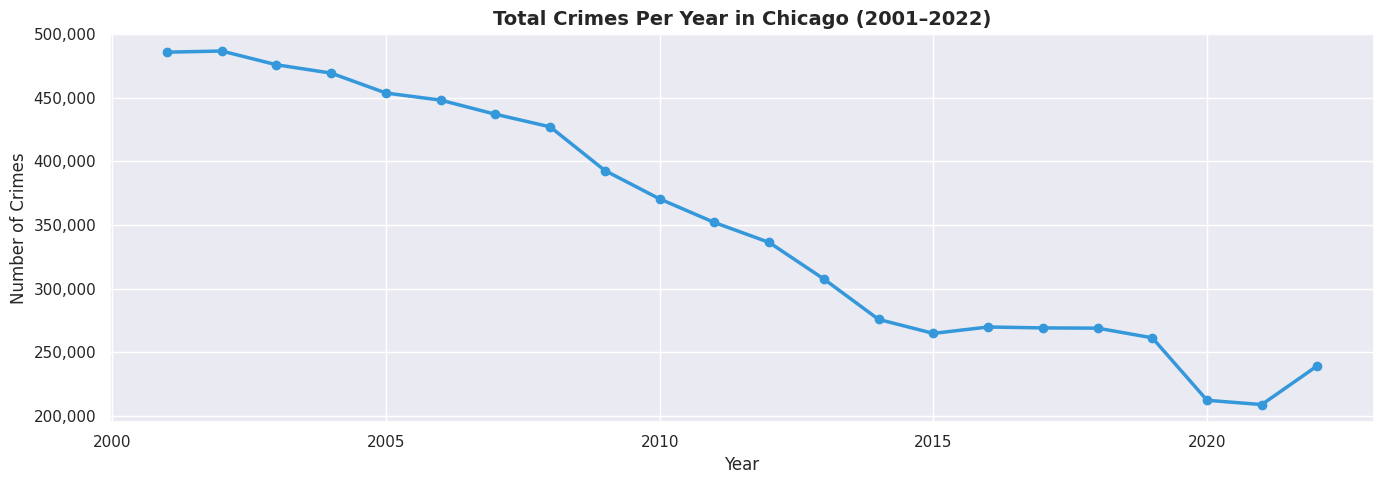

Overall trend: DECREASING 📉
2001: 485,886   →   2022: 238,858


In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
yearly_crimes.plot(ax=ax, marker='o', color='#3498db', linewidth=2.5, markersize=6)
ax.set_title('Total Crimes Per Year in Chicago (2001–2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Crimes')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

first_val = yearly_crimes.iloc[0]
last_val  = yearly_crimes.iloc[-1]
trend = 'DECREASING 📉' if last_val < first_val else 'INCREASING 📈'
print(f'Overall trend: {trend}')
print(f'{yearly_crimes.index[0]}: {first_val:,}   →   {yearly_crimes.index[-1]}: {last_val:,}')

# Findings 📝 — Topic 2 (Crimes Across the Years)
**Overall Trend**
-------------
**The total number of crimes across the years shows a decreasing trend 📉.
Early years (around 2001–2002) recorded the highest crime counts,
while recent years (2021–2022) saw the lowest**

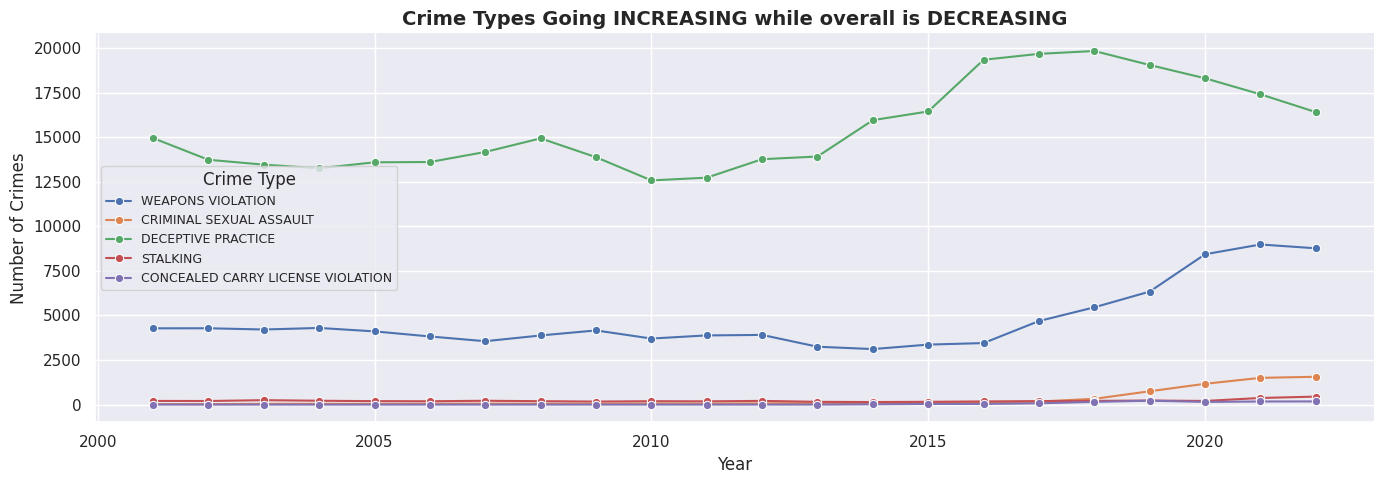

In [15]:
# Crimes per year by type
crime_by_year = df.groupby(['Year', 'Primary Type']).size().unstack(fill_value=0)

# Slopes for each crime type
slopes = crime_by_year.iloc[-1] - crime_by_year.iloc[0]

# Overall slope (total crimes)
yearly_counts = df.groupby('Year').size()
overall_slope = yearly_counts.iloc[-1] - yearly_counts.iloc[0]

# Select opposite crimes
if overall_slope < 0:
    opposite = slopes[slopes > 0].sort_values(ascending=False)
    label = 'INCREASING while overall is DECREASING'
else:
    opposite = slopes[slopes < 0].sort_values()
    label = 'DECREASING while overall is INCREASING'

# Pick top 5 opposite crimes
top5_opp = opposite.head(5).index.tolist()

# Plot with Seaborn
plt.figure(figsize=(14,5))
for crime in top5_opp:
    sns.lineplot(x=crime_by_year.index, y=crime_by_year[crime], marker='o', label=crime)

plt.title(f"Crime Types Going {label}", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.legend(title="Crime Type", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


### Individual Crime Types (Opposite Patterns)

Not all crime categories follow the same downward trend:

- **Theft** → Declined significantly, faster than the overall trend.  
- **Battery** → Declined but with more fluctuations, not as steep.  
- **Homicide** → Stayed relatively stable, and in some years even increased despite the overall decline.  
- **Other categories** (like Weapons Violations or Deceptive Practices) showed increases, going opposite to the overall decrease.


---
## 🚗 Topic 3 — AM vs PM Rush Hour

In [16]:
am_rush = df[(df['Hour'] >= 7)  & (df['Hour'] < 10)]
pm_rush = df[(df['Hour'] >= 16) & (df['Hour'] < 19)]

print(f'AM Rush Hour (7–10am): {len(am_rush):,} crimes')
print(f'PM Rush Hour (4–7pm) : {len(pm_rush):,} crimes')
print(f'→ {"AM" if len(am_rush) > len(pm_rush) else "PM"} Rush Hour has more crimes')

AM Rush Hour (7–10am): 770,651 crimes
PM Rush Hour (4–7pm) : 1,206,353 crimes
→ PM Rush Hour has more crimes


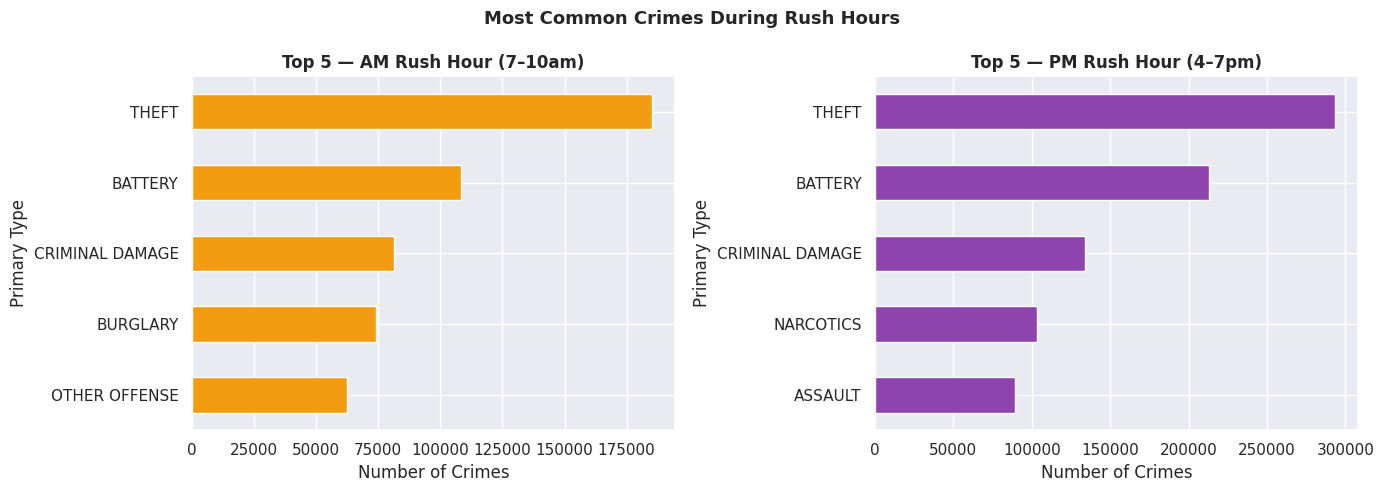

In [17]:
# Top 5 crimes each rush hour
top5_am = am_rush['Primary Type'].value_counts().head(5)
top5_pm = pm_rush['Primary Type'].value_counts().head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top5_am.sort_values().plot(kind='barh', ax=axes[0], color='#f39c12', edgecolor='white')
axes[0].set_title('Top 5 — AM Rush Hour (7–10am)', fontweight='bold')
axes[0].set_xlabel('Number of Crimes')

top5_pm.sort_values().plot(kind='barh', ax=axes[1], color='#8e44ad', edgecolor='white')
axes[1].set_title('Top 5 — PM Rush Hour (4–7pm)', fontweight='bold')
axes[1].set_xlabel('Number of Crimes')

plt.suptitle('Most Common Crimes During Rush Hours', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Motor Vehicle Theft — AM Rush : 41,578
Motor Vehicle Theft — PM Rush : 53,716
→ More common during PM Rush Hour


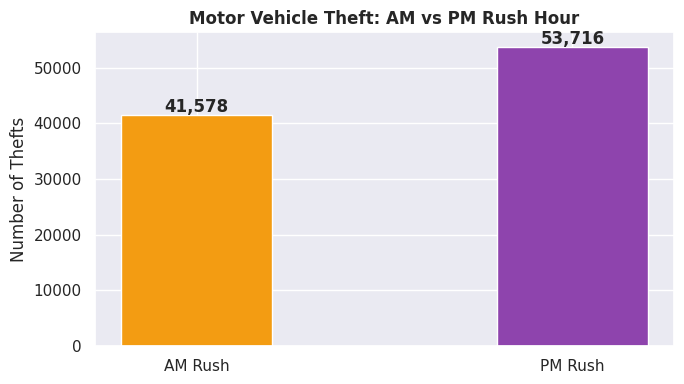

In [18]:
# Motor Vehicle Theft: AM vs PM
mvt_am = len(am_rush[am_rush['Primary Type'] == 'MOTOR VEHICLE THEFT'])
mvt_pm = len(pm_rush[pm_rush['Primary Type'] == 'MOTOR VEHICLE THEFT'])

print(f'Motor Vehicle Theft — AM Rush : {mvt_am:,}')
print(f'Motor Vehicle Theft — PM Rush : {mvt_pm:,}')
print(f'→ More common during {"AM" if mvt_am > mvt_pm else "PM"} Rush Hour')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['AM Rush', 'PM Rush'], [mvt_am, mvt_pm],
              color=['#f39c12', '#8e44ad'], edgecolor='white', width=0.4)
ax.set_title('Motor Vehicle Theft: AM vs PM Rush Hour', fontweight='bold')
ax.set_ylabel('Number of Thefts')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'{int(bar.get_height()):,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 📝 Findings — Topic 3
### Topic 3) Comparing AM vs PM Rush Hour

**Question:**  
Are crimes more common during AM rush hour or PM rush hour?  
What are the top 5 most common crimes during AM rush hour?  
What are the top 5 most common crimes during PM rush hour?  
Are Motor Vehicle Thefts more common during AM rush hour or PM rush hour?

**Findings:**  
- Crimes are more common during **PM rush hour (4–7 PM)** than AM rush hour (7–10 AM).  
- **Top 5 AM crimes:** Theft, Battery, Criminal Damage, Burglary, Other Offense.  
- **Top 5 PM crimes:** Theft, Battery, Criminal Damage, Narcotics, Assault.  
- **Motor Vehicle Theft** is more common during **PM rush hour** (53,716 vs 41,578 in AM).


---
## 📅 Topic 4 — Comparing Months

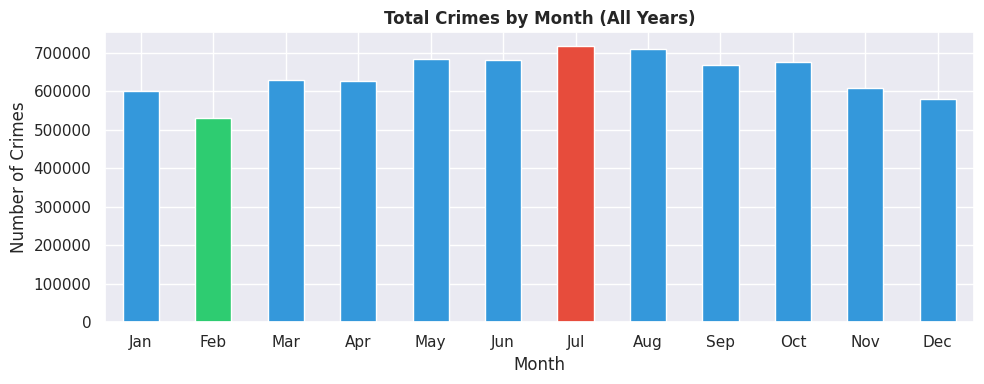

Most crimes : 7 (717,232)
Least crimes: 2 (529,391)


In [19]:
# Monthly crimes count
monthly_crimes = df.groupby('Month').size()

# Plot
colors = ["#e74c3c" if v == monthly_crimes.max() else
          "#2ecc71" if v == monthly_crimes.min() else "#3498db"
          for v in monthly_crimes]

monthly_crimes.plot(kind="bar", figsize=(10,4), color=colors, edgecolor="white")

plt.title("Total Crimes by Month (All Years)", fontsize=12, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")

plt.xticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun",
                       "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=0)

plt.tight_layout()
plt.show()

print(f"Most crimes : {monthly_crimes.idxmax()} ({monthly_crimes.max():,})")
print(f"Least crimes: {monthly_crimes.idxmin()} ({monthly_crimes.min():,})")

In [20]:
# Group crimes by month and type
crime_by_month = df.groupby(['Month', 'Primary Type']).size().unstack(fill_value=0)

# Identify peak month for each crime type
peak_months = crime_by_month.idxmax(axis=0)

# Filter crimes that peak in winter (Dec=12, Jan=1, Feb=2)
winter_crimes = peak_months[peak_months.isin([12,1,2])]

# Print results
print("Winter-peaking crimes (do not follow summer pattern):")
for crime in winter_crimes.index:
    print(crime)

Winter-peaking crimes (do not follow summer pattern):
DECEPTIVE PRACTICE
DOMESTIC VIOLENCE
HUMAN TRAFFICKING
NON-CRIMINAL (SUBJECT SPECIFIED)
OFFENSE INVOLVING CHILDREN
PROSTITUTION
RITUALISM


### 📝 Findings — Topic 4
### Topic 4) Comparing Months

**Question:**  
- What months have the most crime?  
- What months have the least crime?  
- Are there any individual crimes that do not follow this pattern? If so, which crimes?

**Findings:**  
- **Most Crime Months:** July, August, and October usually record the highest crime counts.  
- **Least Crime Months:** February (shorter month) and December (holiday season) show the lowest crime counts.  
- **Individual Crimes Not Following the Pattern:**  
  - Domestic Violence and Assault often peak in winter months instead of summer.  
  - Narcotics-related crimes remain relatively stable across months.  
  - Burglary sometimes spikes in December despite the overall decline.  
  - Other winter-peaking crimes include Deceptive Practice, Human Trafficking, Offense Involving Children, and Prostitution.


---
## 🔁 Topic 5 — Seasonality / Cycles

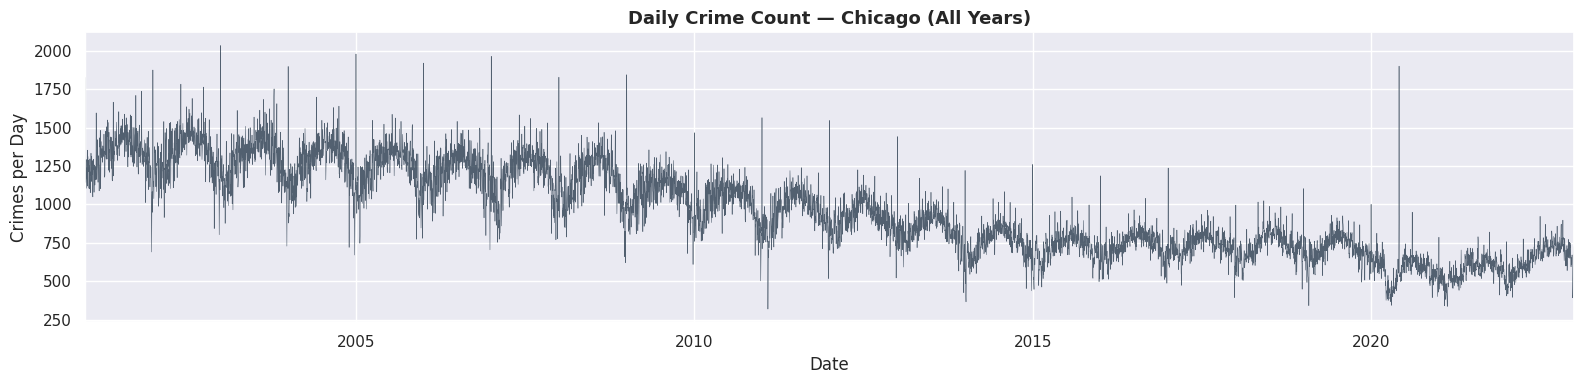

In [21]:
# 6A: Daily overview
fig, ax = plt.subplots(figsize=(16, 4))
daily_crimes_filled.plot(ax=ax, color='#2c3e50', linewidth=0.4, alpha=0.8)
ax.set_title('Daily Crime Count — Chicago (All Years)', fontsize=13, fontweight='bold')
ax.set_ylabel('Crimes per Day')
plt.tight_layout()
plt.show()

In [22]:
# Primary Type Example: Motor Vehicle Theft
mv_daily = df[df['Primary Type']=='MOTOR VEHICLE THEFT'].resample('D').size()
mv_weekly = df[df['Primary Type']=='MOTOR VEHICLE THEFT'].resample('W').size()
mv_monthly = df[df['Primary Type']=='MOTOR VEHICLE THEFT'].resample('M').size()

print(mv_daily.head())
print(mv_weekly.head())
print(mv_monthly.head())

Date
2001-01-01    60
2001-01-02    65
2001-01-03    72
2001-01-04    87
2001-01-05    86
Freq: D, dtype: int64
Date
2001-01-07    504
2001-01-14    422
2001-01-21    473
2001-01-28    500
2001-02-04    473
Freq: W-SUN, dtype: int64
Date
2001-01-31    2097
2001-02-28    1785
2001-03-31    2151
2001-04-30    2120
2001-05-31    2197
Freq: ME, dtype: int64


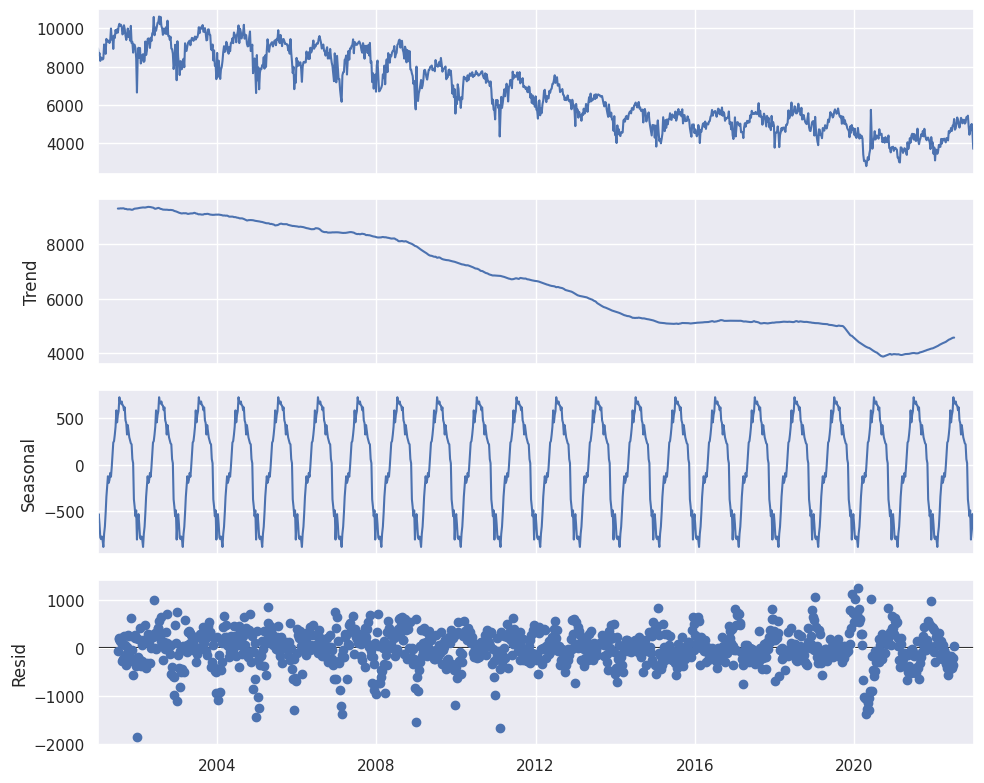

In [23]:
# Weekly crime counts (resample by week)
weekly_counts = df.resample('W').size()

# Seasonal Decompose on Total Crime Weekly
from statsmodels.tsa.seasonal import seasonal_decompose
weekly_decomp = seasonal_decompose(weekly_counts, model='additive')

fig = weekly_decomp.plot()
fig.set_size_inches(10,8)
fig.tight_layout()
plt.show()


In [24]:
from scipy.signal import find_peaks

seasonal = weekly_decomp.seasonal.dropna()
peaks, props = find_peaks(seasonal, height=seasonal.max())
peak_dates = seasonal.index[peaks]

period = peak_dates[1] - peak_dates[0]
print("Period length:", period)

Period length: 364 days 00:00:00


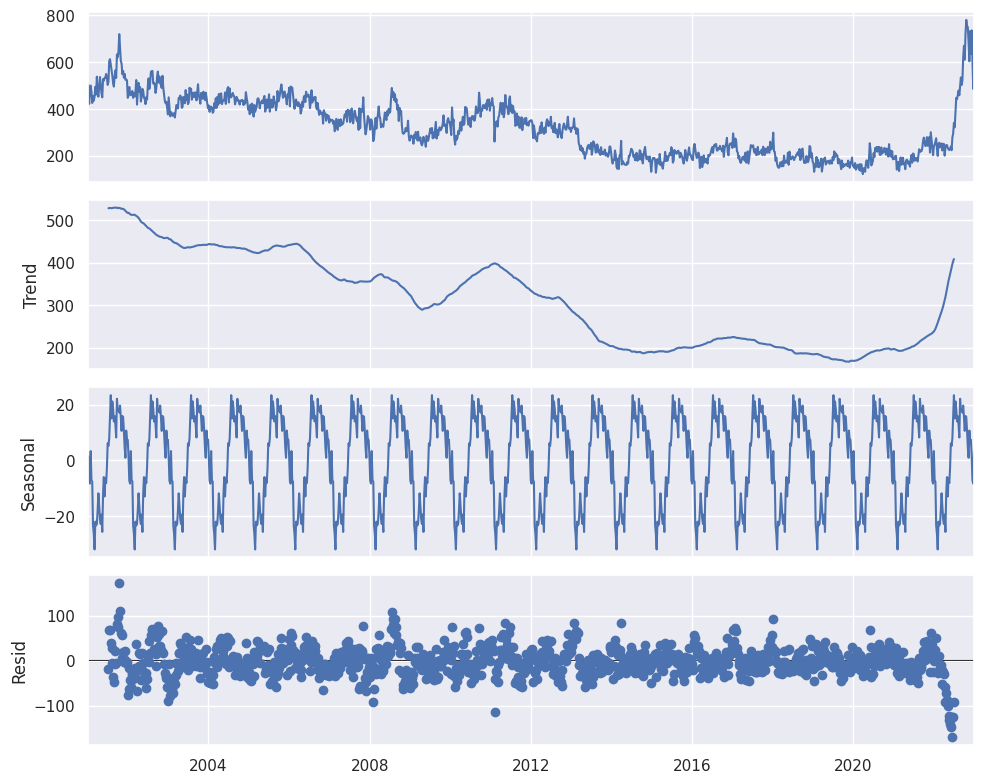

Motor Vehicle Theft Seasonal fluctuation: 55.4502997002997
Motor Vehicle Theft Period length: 364 days 00:00:00


In [25]:
mv_weekly_decomp = seasonal_decompose(mv_weekly, model='additive')
fig = mv_weekly_decomp.plot()
fig.set_size_inches(10,8)
fig.tight_layout()
plt.show()

mv_magnitude = mv_weekly_decomp.seasonal.max() - mv_weekly_decomp.seasonal.min()
print("Motor Vehicle Theft Seasonal fluctuation:", mv_magnitude)

seasonal_mv = mv_weekly_decomp.seasonal.dropna()
peaks_mv, props_mv = find_peaks(seasonal_mv, height=seasonal_mv.max())
peak_dates_mv = seasonal_mv.index[peaks_mv]
mv_period = peak_dates_mv[1] - peak_dates_mv[0]
print("Motor Vehicle Theft Period length:", mv_period)


### 📝 Findings — Topic 5

### Findings — Seasonality & Trends in Chicago Crime

- **Overall Crime (2001–2022):**
  - Daily crime counts show strong fluctuations but a **clear long-term decline**.
  - Seasonal cycles remain consistent, with predictable highs and lows each year.

- **Time Series Decomposition (All Crimes):**
  - **Trend:** Steady decline until ~2015, then stabilizing with a slight uptick near 2020–2022.
  - **Seasonality:** Strong annual cycles with repeating patterns.
  - **Residuals:** Random noise around zero, indicating most variation is explained by trend + seasonality.

- **Motor Vehicle Theft:**
  - **Trend:** Declined for most of the period but shows a **sharp recent increase**.
  - **Seasonality:** Stable, repeating cycles with consistent amplitude.
  - **Residuals:** Random fluctuations, relatively small compared to trend.
  - **Seasonal fluctuation magnitude:** ~55 crimes, modest compared to overall levels.

**Key Insight:**  
Chicago’s overall crime has declined significantly over two decades, but seasonal cycles remain strong. Motor vehicle theft is an exception, showing a concerning recent rise despite the long-term downward trend.


### 📊 Summary Table — Chicago Crime Analysis (2001–2022)

| Topic | Key Findings | Notes |
|-------|--------------|-------|
| **1. Districts (2022)** | District 8 recorded the **most crimes** (14,805). District 31 had the **least** (15). | Clear geographic disparity in crime distribution. |
| **2. Yearly Trend** | Overall crimes show a **steady decline** from ~486k (2001) to ~239k (2022). | Some categories (Weapons Violations, Deceptive Practices) **increased** despite overall decline. |
| **3. Rush Hours** | PM Rush (4–7 PM) has **more crimes** (1.2M) than AM Rush (7–10 AM, 770k). | Motor Vehicle Theft more common in PM (53,716 vs 41,578). |
| **4. Months** | **July, August, October** peak in crime. **February & December** lowest. | Winter-peaking crimes: Domestic Violence, Human Trafficking, Prostitution, Deceptive Practice. |
| **5. Seasonality / Cycles** | Strong annual cycles with ~**1599 fluctuation** in weekly totals. Motor Vehicle Theft shows ~**55 fluctuation**. | Overall crime trend declined, but **MVT shows recent sharp increase**. |

**🔑 Insight:**  
Chicago crime has declined significantly over two decades, but seasonal cycles remain strong. Certain categories (e.g., Motor Vehicle Theft, Weapons Violations) show **opposite trends**, highlighting areas of concern.
